In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, chi2

In [2]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print(df.info())
print()

print(df.describe())
print()

print("Shape:", df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.4865

In [4]:

print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [5]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

df.drop("Cabin", axis=1, inplace=True)

print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [6]:
df.drop(["PassengerId","Name","Ticket"], axis=1, inplace=True)

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [7]:
encoder = LabelEncoder()

df["Sex"] = encoder.fit_transform(df["Sex"])
df["Embarked"] = encoder.fit_transform(df["Embarked"])

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


In [8]:
print("Duplicates:", df.duplicated().sum())

df = df.drop_duplicates()

print("New Shape:", df.shape)

Duplicates: 116
New Shape: (775, 8)


In [9]:
normalizer = MinMaxScaler()

cols = ["Age","Fare","SibSp","Parch"]

df[cols] = normalizer.fit_transform(df[cols])

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,0.271174,0.125,0.0,0.014151,2
1,1,1,0,0.472229,0.125,0.0,0.139136,0
2,1,3,0,0.321438,0.000,0.0,0.015469,2
3,1,1,0,0.434531,0.125,0.0,0.103644,2
4,0,3,1,0.434531,0.000,0.0,0.015713,2


In [10]:
scaler = StandardScaler()

df[cols] = scaler.fit_transform(df[cols])

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,-0.551060,0.475876,-0.500754,-0.527515,2
1,1,1,0,0.611945,0.475876,-0.500754,0.695086,0
2,1,3,0,-0.260308,-0.534545,-0.500754,-0.514627,2
3,1,1,0,0.393881,0.475876,-0.500754,0.347909,2
4,0,3,1,0.393881,-0.534545,-0.500754,-0.512240,2


In [11]:
df["Fare_Log"] = np.log1p(df["Fare"] - df["Fare"].min() + 1)

df[["Fare","Fare_Log"]].head()

,Fare,Fare_Log
0,-0.527515,0.760070
1,0.695086,1.212247
2,-0.514627,0.766079
3,0.347909,1.103218
4,-0.512240,0.767187


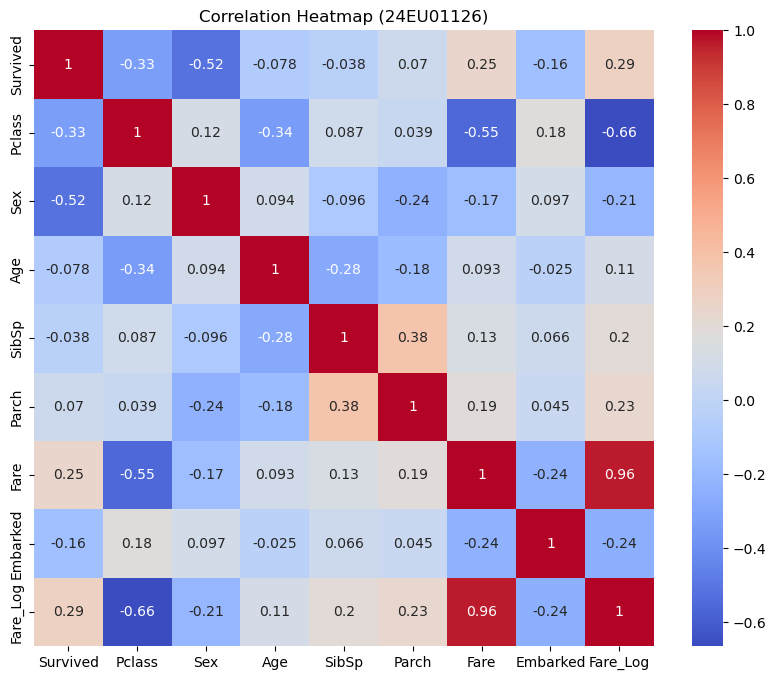

In [12]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap (24EU01126)")
plt.show()

In [13]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [14]:
pca = PCA()

X_pca = pca.fit_transform(X_scaled)

print(pca.explained_variance_ratio_)

[0.33931077 0.21673058 0.12347364 0.11100878 0.08570523 0.07219681
 0.04890034 0.00267385]
